<div style="background:linear-gradient(135deg,#1b5e20,#2e7d32,#388e3c);padding:36px 28px;border-radius:14px;color:#fff;text-align:center">
<h1 style="margin:0;font-size:2.2em">🔩 Notebook 3 — PFR Isotérmico y No Isotérmico</h1>
<h2 style="margin:10px 0 4px;font-weight:300;opacity:.92">Capítulos 2, 5, 6 y 8 · Fogler 4ª Ed.</h2>
<p style="margin:4px 0 0;opacity:.85">740484 Diseño de Reactores · Maestría Ingeniería Química · Universidad del Valle</p>
</div>

---

## 🎯 Objetivos

1. Derivar la ecuación de diseño del PFR y comparar con el CSTR.
2. Resolver el PFR no isotérmico como sistema de ODEs acopladas.
3. Modelar la caída de presión en PFR con lecho empacado (ecuación de Ergun).
4. Calcular selectividad y rendimiento en reacciones en paralelo.
5. Encontrar el volumen óptimo para reacciones en serie A→B→C.

## 📚 Mapa de referencias — Fogler 4ª Ed.

| Tema | Sección | Ecuación clave |
|------|---------|----------------|
| Ecuación de diseño PFR | §2.2, Ec. 2-15 | $V = F_{A0}\int_0^X dX/(-r_A)$ |
| Caída de presión (Ergun) | §5.4, Ec. 5-28 | $dy/dW = -\alpha/(2y)\cdot F_T/F_{T0}$ |
| Selectividad instantánea | §6.1, Ec. 6-1 | $\tilde{S}_{D/U} = r_D/r_U$ |
| Reacciones en serie | §6.2 | $\tau_{opt} = \ln(k_2/k_1)/(k_2-k_1)$ |
| PFR no isotérmico | §8.6, Ec. 8-53,55 | ODEs: $dX/dV$ y $dT/dV$ |

## 🏭 Contexto industrial del PFR

El reactor tubular de flujo pistón es el **caballo de batalla de la petroquímica**:

- **Steam cracking de etano/nafta** (Linde, KBR, Lummus): hornos tubulares a 850°C, τ ≈ 0.5 s.
- **Reformado catalítico** (UOP, Axens): lechos de Pt-Re/Al₂O₃ en serie con reheaters.
- **Síntesis de amoniaco** (Haber-Bosch): lechos de Fe a 400-500°C, 150-200 bar.
- **Oxidación parcial de etileno** a óxido de etileno (Shell, SD/UCC).
- **Hidrotratamiento y hidrocraqueo** de fracciones petrolíferas.

En todos estos procesos, el control del perfil de temperatura a lo largo del tubo es crítico para la selectividad y la vida del catalizador.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patheffects import withStroke
from scipy.integrate import odeint, cumulative_trapezoid
from scipy.optimize import brentq
from ipywidgets import interact, FloatSlider
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':11,'axes.grid':True,
    'grid.alpha':0.28,'figure.dpi':110,'axes.titleweight':'bold',
    'lines.linewidth':2.3,'axes.titlesize':11.5,
    'axes.spines.top':False,'axes.spines.right':False,
})
print('Entorno listo.')


Entorno listo.


---
# 1. Ecuación de diseño del PFR — derivación y comparación

## 1.1 Balance molar diferencial (Fogler §2.2)

El PFR opera sin mezcla axial: la composición varía continuamente con el volumen $V$. Para un diferencial $dV$:

$$F_A(V) - F_A(V+dV) + r_A\,dV = 0 \implies \frac{dF_A}{dV} = r_A$$

Sustituyendo $F_A = F_{A0}(1-X)$ en estado estacionario:

$$\boxed{F_{A0}\frac{dX}{dV} = -r_A(X,T) \tag{2-15}}$$

Integrando de $V=0$ (X=0) a $V$ (X=X_A):

$$V_\text{PFR} = F_{A0}\int_0^{X_A}\frac{dX}{-r_A}$$

## 1.2 Diferencia fundamental con el CSTR

| Aspecto | CSTR | PFR/Batch |
|---------|------|-----------|
| Balance molar | **Álgebra**: $V = F_{A0}X/(-r_A)|_{sal}$ | **ODE**: $dX/dV = -r_A/F_{A0}$ |
| Concentración | Uniforme = salida (mínima) | Varía: alta (entrada) → baja (salida) |
| Velocidad rxn | Fija = mínima posible | Varía continuamente, promedio mayor |
| Volumen ($n>0$) | **Mayor** (penalizado) | **Menor** |
| Gráfico Levenspiel | Rectángulo (área sobreestimada) | Área exacta bajo la curva |

## 1.3 PFR no isotérmico — ODEs acopladas (Fogler §8.6)

Para el PFR con intercambio de calor con la camisa ($T_a$ = temperatura fluido exterior):

$$\frac{dX}{dV} = \frac{-r_A}{F_{A0}} \tag{8-53}$$

$$\frac{dT}{dV} = \frac{Ua(T_a-T)+(-r_A)(-\Delta H_{rx})}{F_{A0}\cdot\sum_i\Theta_iC_{p,i}} \tag{8-55}$$

donde $Ua$ [kJ/(dm³·min·K)] = coeficiente global por unidad de volumen del reactor.

**Análisis de casos límite:**

| Condición | Efecto |
|-----------|--------|
| $Ua\to\infty$ | $T\to T_a$ en todo el reactor — isotérmico a $T_a$ |
| $Ua=0$ | Sin intercambio — PFR adiabático ($T = T_0 + \Delta T_{ad}\cdot X$) |
| $T_a > T_0$ (exotérmico) | La camisa enfría el reactor, mejora selectividad térmica |
| $T_a < T_0$ (endotérmico) | La camisa aporta calor, evita extinción de la reacción |


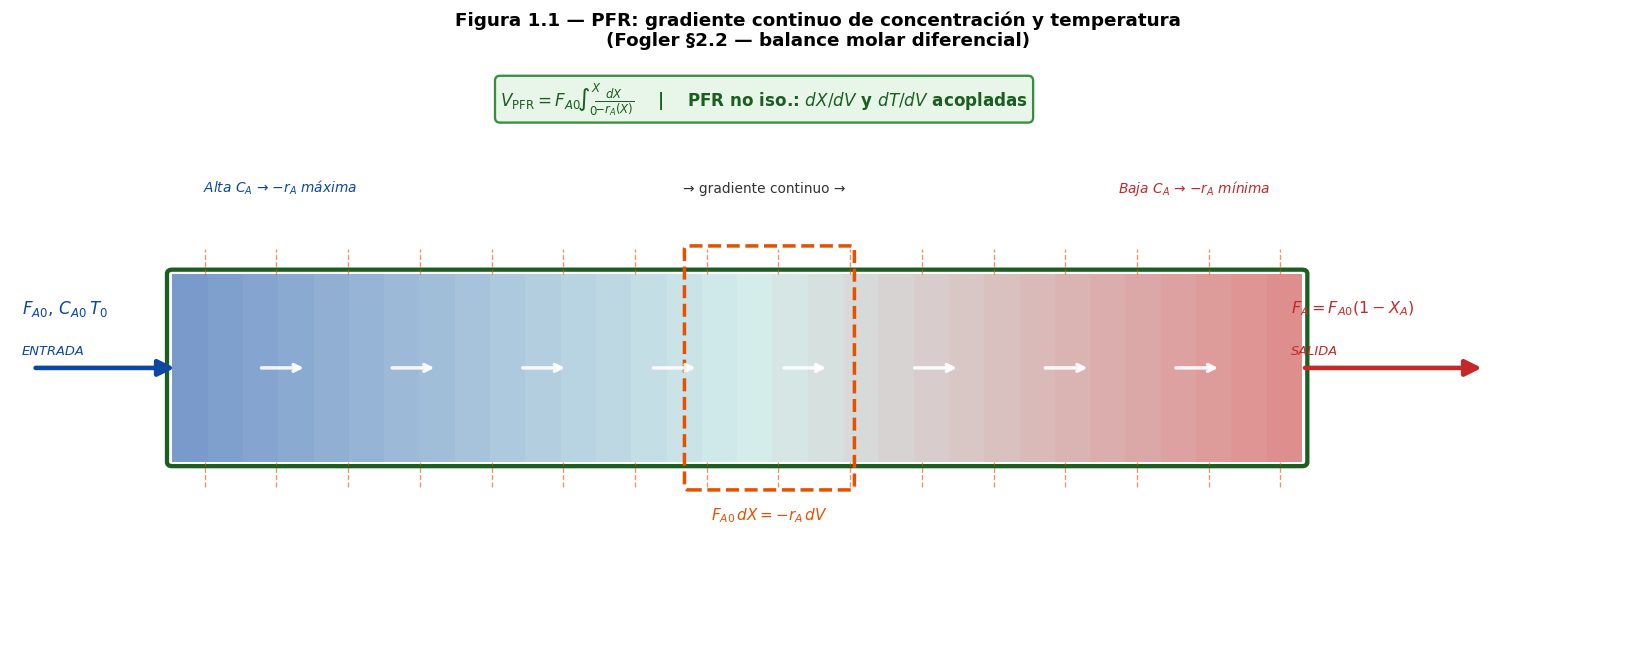

Figura 1.1 generada.


In [6]:
# Figura 1.1 — Diagrama PFR con gradiente de concentración
pe = [withStroke(linewidth=3, foreground='white')]
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_xlim(0, 15); ax.set_ylim(0, 7)
ax.axis('off'); ax.set_facecolor('#f0f4f0')

# Gradiente de color en el tubo
cmap = LinearSegmentedColormap.from_list('pfr',['#0D47A1','#B2DFDB','#C62828'])
n_seg = 32
for i in range(n_seg):
    xs = 1.5 + i*(10.5/n_seg)
    rect = Rectangle((xs, 2.1), 10.5/n_seg, 2.3,
                     facecolor=cmap(i/n_seg), alpha=0.55, edgecolor='none')
    ax.add_patch(rect)

# Contorno del tubo
tube = FancyBboxPatch((1.5, 2.1), 10.5, 2.3,
                      boxstyle='round,pad=0.05',
                      facecolor='none', edgecolor='#1B5E20', lw=2.8)
ax.add_patch(tube)

# Flechas de flujo
for x in np.linspace(2.3, 10.8, 8):
    ax.annotate('', xy=(x+0.45, 3.25), xytext=(x, 3.25),
                arrowprops=dict(arrowstyle='->', color='white', lw=2.3, alpha=0.9))

# Camisa (líneas punteadas)
for x in np.linspace(1.8, 11.8, 16):
    ax.plot([x,x],[1.8,2.1],'--', color='#E65100', lw=0.9, alpha=0.6)
    ax.plot([x,x],[4.4,4.7],'--', color='#E65100', lw=0.9, alpha=0.6)

# Entrada y salida
ax.annotate('', xy=(1.55, 3.25), xytext=(0.2, 3.25),
            arrowprops=dict(arrowstyle='-|>', color='#0D47A1', lw=3.0, mutation_scale=22))
ax.text(0.1, 3.92, r'$F_{A0},\,C_{A0}\,T_0$',
        fontsize=11, color='#0D47A1', fontweight='bold')
ax.text(0.1, 3.42, 'ENTRADA', fontsize=8.5, color='#0D47A1', style='italic')

ax.annotate('', xy=(13.7, 3.25), xytext=(12.0, 3.25),
            arrowprops=dict(arrowstyle='-|>', color='#C62828', lw=3.0, mutation_scale=22))
ax.text(11.9, 3.92, r'$F_A=F_{A0}(1-X_A)$',
        fontsize=10.5, color='#C62828', fontweight='bold')
ax.text(11.9, 3.42, 'SALIDA', fontsize=8.5, color='#C62828', style='italic')

# Diferencial dV
dv = FancyBboxPatch((6.3, 1.8), 1.5, 2.9,
                    boxstyle='round,pad=0.04',
                    facecolor='none', edgecolor='#E65100', lw=2.3, ls='--')
ax.add_patch(dv)
ax.text(7.05, 1.4, r'$F_{A0}\,dX = -r_A\,dV$',
        fontsize=10, ha='center', color='#E65100', fontweight='bold')

# Anotaciones de perfil
ax.text(2.5, 5.4, r'Alta $C_A$ → $-r_A$ máxima', fontsize=9,
        color='#0D47A1', ha='center', style='italic')
ax.text(11.0, 5.4, r'Baja $C_A$ → $-r_A$ mínima', fontsize=9,
        color='#C62828', ha='center', style='italic')
ax.text(7.0, 5.4, '→ gradiente continuo →', fontsize=9, color='#333', ha='center')

# Ecuación principal
ax.text(7.0, 6.45,
        r'$V_\mathrm{PFR} = F_{A0}\!\int_0^X\!\!\frac{dX}{-r_A(X)}$'
        r'    |    PFR no iso.: $dX/dV$ y $dT/dV$ acopladas',
        ha='center', fontsize=11, fontweight='bold', color='#1B5E20',
        bbox=dict(boxstyle='round', facecolor='#E8F5E9',
                  edgecolor='#388E3C', lw=1.5))

ax.set_title('Figura 1.1 — PFR: gradiente continuo de concentración y temperatura\n'
             '(Fogler §2.2 — balance molar diferencial)',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('/content/fig_nb3_pfr.png', dpi=130,
            bbox_inches='tight', facecolor='#f0f4f0')
plt.show()
print('Figura 1.1 generada.')

---
# 2. PFR no isotérmico — resolución numérica interactiva

## 2.1 Implementación numérica

El sistema de ODEs se integra con `scipy.integrate.odeint` usando el esquema de Adams-Moulton (adaptativo). La condición inicial es $[X(0), T(0)] = [0, T_0]$.

## 2.2 Análisis del espacio de fase X-T

El plano $(T, X)$ es la herramienta más informativa para entender el comportamiento global del PFR no isotérmico:

- **Trayectoria curvada hacia la derecha** (T > Tₐ): la reacción genera más calor del que la camisa extrae.
- **Trayectoria curvada hacia la izquierda** (T < Tₐ): la camisa aporta calor (endotérmica o T₀ < Tₐ).
- **Línea adiabática** (trazo naranja): trayectoria ideal con $Ua=0$; pendiente = $\Delta T_{ad}/\Delta X$.

## 2.3 Comparación de tres regímenes

| Régimen | Ua | T_salida | X_salida | Uso industrial |
|---------|----|---------|---------|----------------|
| Isotérmico | → ∞ | T₀ | $1-e^{-k\tau}$ | Reacciones lentas, catalizador sensible |
| No isotérmico | Moderado | T₀ < T < T₀+ΔTad | Intermedio | Caso general |
| Adiabático | 0 | T₀ + ΔTad·X | Máxima | Reacciones rápidas, alta conversión |

## 2.4 Ejercicio guiado

1. Comience con $Ua=0$ (adiabático) y observe que la trayectoria en X-T sigue exactamente la línea adiabática.
2. Aumente $Ua$ gradualmente: la T de salida baja y la conversión cambia.
3. Con $Ua=20$ y $T_a=350$ K (mayor que T₀): observe cómo la camisa aporta calor en la entrada donde T < Tₐ.


In [3]:
# PFR no isotérmico — 4 paneles interactivos
R_p=8.314e-3; k0_p=7.08e10; Ea_p=75.36
CA0_p=2.0; FA0_p=2.0; CpA_p=0.167

def k_pfr(T): return k0_p*np.exp(-Ea_p/(R_p*T))

def plot_pfr_ni(Ua=4.0, Ta=310., T0=300., V_max=50., dH=-80.):
    def odes(y, V):
        X_, T_ = y
        X_ = max(0, min(X_, 0.9999)); T_ = max(T_, 250)
        rA = k_pfr(T_) * CA0_p * (1 - X_)
        dX = rA / FA0_p
        dT = (Ua*(Ta-T_) + (-rA)*(-dH)) / (FA0_p*CpA_p)
        return [dX, dT]

    def odes_iso(y, V):
        X_ = max(0, min(y[0], 0.9999))
        rA = k_pfr(T0) * CA0_p * (1 - X_)
        return [rA/FA0_p, 0]

    def odes_adia(y, V):
        X_, T_ = y
        X_ = max(0, min(X_, 0.9999)); T_ = max(T_, 250)
        rA = k_pfr(T_) * CA0_p * (1 - X_)
        return [rA/FA0_p, (-rA)*(-dH)/(FA0_p*CpA_p)]

    V_ = np.linspace(0, V_max, 2000)
    sol      = odeint(odes,      [0., T0], V_)
    sol_iso  = odeint(odes_iso,  [0., T0], V_)
    sol_adia = odeint(odes_adia, [0., T0], V_)

    X_    = np.clip(sol[:,0], 0, 1);  T_    = sol[:,1]
    X_iso = np.clip(sol_iso[:,0], 0, 1)
    X_ad  = np.clip(sol_adia[:,0], 0, 1); T_ad = sol_adia[:,1]
    dTad  = (-dH)/CpA_p

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'PFR No Isotérmico — Ua={Ua:.1f} kJ/dm³·min·K, '
                 f'Ta={Ta:.0f}K, ΔH={dH:.0f} kJ/mol',
                 fontsize=12, fontweight='bold', y=1.01)

    # X(V)
    axes[0,0].plot(V_, X_,    '#C62828', lw=2.8, label=f'No iso. (Ua={Ua:.1f})')
    axes[0,0].plot(V_, X_iso, 'gray',    lw=2.0, ls='--', label=f'Isotérmico T={T0:.0f}K')
    axes[0,0].plot(V_, X_ad,  '#E65100', lw=2.0, ls=':',  label='Adiabático')
    axes[0,0].set_xlabel('V [L]'); axes[0,0].set_ylabel('$X_A$')
    axes[0,0].set_title('Conversión vs V\n(Fogler §8.6, Ec. 8-53)')
    axes[0,0].legend(fontsize=9); axes[0,0].set_ylim(0, 1.05)

    # T(V)
    axes[0,1].plot(V_, T_,   '#C62828', lw=2.8, label='T no isotérmico')
    axes[0,1].plot(V_, T_ad, '#E65100', lw=2.0, ls=':', label='T adiabático')
    axes[0,1].axhline(T0, color='gray',    ls='--', lw=1.5, label=f'T₀={T0:.0f}K')
    axes[0,1].axhline(Ta, color='#0D47A1', ls='-.', lw=1.8, label=f'Tₐ={Ta:.0f}K')
    axes[0,1].axhline(T0+dTad, color='#C62828', ls=':', lw=1.3,
                      label=f'T_ad_max={T0+dTad:.0f}K', alpha=0.7)
    axes[0,1].set_xlabel('V [L]'); axes[0,1].set_ylabel('T [K]')
    axes[0,1].set_title('Perfil de temperatura')
    axes[0,1].legend(fontsize=8.5)

    # Espacio de fase X-T
    Xr = np.linspace(0, X_[-1]*1.05, 80)
    axes[1,0].plot(T_,   X_,   '#0D47A1', lw=2.8, label='Trayectoria no iso.')
    axes[1,0].plot(T_ad, X_ad, '#E65100', lw=2.0, ls=':', label='Trayectoria adia.')
    axes[1,0].plot(T0+dTad*Xr, Xr, 'orange', ls='--', lw=1.8, alpha=0.85,
                   label=f'Línea adiabática\nΔT_ad={dTad:.1f}K')
    axes[1,0].scatter([T0],     [0],       color='#2E7D32', s=150, zorder=9,
                      edgecolors='black', label='Entrada')
    axes[1,0].scatter([T_[-1]], [X_[-1]],  color='#C62828', s=150, zorder=9,
                      edgecolors='black', label=f'Salida X={X_[-1]:.3f}')
    axes[1,0].set_xlabel('T [K]'); axes[1,0].set_ylabel('$X_A$')
    axes[1,0].set_title('Espacio de fase X-T\n(trayectoria dinámica del reactor)')
    axes[1,0].legend(fontsize=8.5)

    # Perfil de k(T) a lo largo del reactor
    k_arr = [k_pfr(Ti) for Ti in T_]
    k_iso = [k_pfr(T0)]*len(V_)
    axes[1,1].semilogy(V_, k_arr, '#C62828', lw=2.8, label='k(T) no isotérmico')
    axes[1,1].semilogy(V_, k_iso, 'gray', lw=2.0, ls='--', label=f'k isotérmico T={T0:.0f}K')
    axes[1,1].set_xlabel('V [L]'); axes[1,1].set_ylabel('k [min⁻¹] (escala log)')
    axes[1,1].set_title('Perfil de k(T)\n(Arrhenius amplifica efecto de T)')
    axes[1,1].legend(fontsize=9)

    plt.tight_layout(); plt.show()
    print(f'  X no iso={X_[-1]:.4f} | X iso={X_iso[-1]:.4f} | X adia={X_ad[-1]:.4f}')
    print(f'  T_max={T_.max():.2f}K | T_salida={T_[-1]:.2f}K | ΔT_ad={dTad:.1f}K')

interact(plot_pfr_ni,
    Ua   =FloatSlider(value=4.0,  min=0.0,  max=40.0, step=0.5,
                      description='Ua [kJ/dm³·min·K]',
                      style={'description_width':'180px'}),
    Ta   =FloatSlider(value=310., min=270.,  max=420., step=2.,
                      description='Tₐ [K]',
                      style={'description_width':'180px'}),
    T0   =FloatSlider(value=300., min=275.,  max=340., step=2.,
                      description='T₀ [K]',
                      style={'description_width':'180px'}),
    V_max=FloatSlider(value=50.,  min=5.,   max=300., step=5.,
                      description='V_max [L]',
                      style={'description_width':'180px'}),
    dH   =FloatSlider(value=-80., min=-250., max=-5.,  step=5.,
                      description='ΔH [kJ/mol]',
                      style={'description_width':'180px'})
);


interactive(children=(FloatSlider(value=4.0, description='Ua [kJ/dm³·min·K]', max=40.0, step=0.5, style=Slider…

---
# 3. Reacciones en paralelo — selectividad (Fogler §6.1)

## 3.1 Planteamiento

$$A \xrightarrow{k_1} D \;\text{(deseado, orden }\alpha_1\text{)} \qquad A \xrightarrow{k_2} U \;\text{(indeseado, orden }\alpha_2\text{)}$$

**Selectividad instantánea** (Fogler §6.1.1, Ec. 6-1):

$$\tilde{S}_{D/U} = \frac{r_D}{r_U} = \frac{k_1}{k_2}\,C_A^{\alpha_1-\alpha_2}$$

**Regla de diseño:**

| Situación | Reactor óptimo | Razón |
|-----------|---------------|-------|
| $\alpha_1 > \alpha_2$ | **PFR / Batch** | Alta $C_A$ favorece D — PFR opera con $C_A$ decreciente (promedio > CSTR) |
| $\alpha_1 < \alpha_2$ | **CSTR** | Baja $C_A$ favorece D — CSTR opera a $C_A$ de salida (mínima) |
| $\alpha_1 = \alpha_2$ | Indiferente | Selectividad solo depende de $k_1/k_2$ |

## 3.2 Selectividad acumulada y rendimiento

$$S_{D} = \frac{F_D - F_{D0}}{F_D + F_U - F_{D0} - F_{U0}} = \frac{\text{moles de D producidos}}{\text{total moles producidos}}$$

$$\Phi_D = \frac{F_D - F_{D0}}{F_{A0} - F_A} = \frac{\text{moles de D producidos}}{\text{moles de A consumidos}}$$


In [4]:
def pfr_paralelo(k1=0.4, k2=0.01, alfa1=1.0, alfa2=2.0,
                CA0=2.0, v0=2.0, V_max=60.):
    FA0_ = CA0*v0
    def odes(y, V):
        FA, FD, FU = y
        FA=max(FA,1e-10); FD=max(FD,0); FU=max(FU,0)
        CA = FA/v0
        rD = k1*CA**alfa1; rU = k2*CA**alfa2
        return [-(rD+rU), rD, rU]

    V_ = np.linspace(0, V_max, 2000)
    sol = odeint(odes, [FA0_, 0., 0.], V_)
    FA_s, FD_s, FU_s = sol[:,0], sol[:,1], sol[:,2]
    X_s  = (FA0_ - FA_s) / FA0_
    CA_s = np.maximum(FA_s/v0, 1e-10)
    S_acum = np.where(FD_s+FU_s>1e-12, FD_s/(FD_s+FU_s), 1.)
    Phi_D  = np.where(FA0_-FA_s>1e-12, FD_s/(FA0_-FA_s), 0.)
    V_opt  = V_[np.argmax(FD_s/v0)]
    CD_max = (FD_s/v0).max()

    # Selectividad CSTR (opera a C_A de salida)
    CA_cstr = np.maximum(CA0*(1-X_s), 1e-10)
    S_cstr  = k1*CA_cstr**alfa1/(k1*CA_cstr**alfa1 + k2*CA_cstr**alfa2)
    rec = 'PFR/Batch' if alfa1>alfa2 else ('CSTR' if alfa1<alfa2 else 'Indiferente')

    fig = plt.figure(figsize=(17, 6.5))
    gs  = fig.add_gridspec(1, 4, width_ratios=[2, 2, 2, 1.5])
    axs = [fig.add_subplot(gs[i]) for i in range(4)]

    # Perfiles de concentración
    axs[0].plot(V_, FA_s/v0, '#0D47A1', lw=2.8, label='$C_A$ (reactivo)')
    axs[0].plot(V_, FD_s/v0, '#2E7D32', lw=2.8, label='$C_D$ (deseado)')
    axs[0].plot(V_, FU_s/v0, '#C62828', lw=2.3, ls='--', label='$C_U$ (indeseado)')
    axs[0].axvline(V_opt, color='gold', ls='--', lw=2.5,
                   label=f'V_opt={V_opt:.1f}L\nCD_max={CD_max:.4f}')
    axs[0].set_xlabel('V [L]'); axs[0].set_ylabel('C [mol/L]')
    axs[0].set_title(f'Perfiles en PFR\nα₁={alfa1:.1f}, α₂={alfa2:.1f}  (Fogler §6.1)')
    axs[0].legend(fontsize=8.5)

    # Selectividad PFR vs CSTR
    axs[1].plot(X_s, S_acum, '#2E7D32', lw=2.8, label='Sel. acumulada PFR')
    axs[1].plot(X_s, S_cstr, '#C62828', lw=2.3, ls='--', label='Sel. CSTR')
    axs[1].set_xlabel('Conversión $X_A$'); axs[1].set_ylabel('Selectividad')
    axs[1].set_title('PFR vs CSTR: selectividad\n(Fogler §6.1.1)')
    axs[1].legend(fontsize=9); axs[1].set_ylim(0, 1.05)

    # Rendimiento
    axs[2].plot(V_, FD_s/FA0_, '#2E7D32', lw=2.8, label='Rendimiento en D')
    axs[2].plot(V_, FU_s/FA0_, '#C62828', lw=2.3, ls='--', label='Fracción en U')
    axs[2].plot(V_, X_s, 'navy', lw=2.0, ls=':', label='Conversión X')
    axs[2].axvline(V_opt, color='gold', ls='--', lw=2.5)
    axs[2].set_xlabel('V [L]'); axs[2].set_ylabel('Fracción de FA0')
    axs[2].set_title('Rendimiento y conversión')
    axs[2].legend(fontsize=9)

    # Tabla de diseño
    axs[3].axis('off')
    rows = [['Parámetro', 'Valor'],
            ['k₁', f'{k1:.3f}'], ['k₂', f'{k2:.3f}'],
            ['α₁', f'{alfa1:.1f}'], ['α₂', f'{alfa2:.1f}'],
            ['α₁−α₂', f'{alfa1-alfa2:+.1f}'],
            ['Reactor óptimo', rec],
            ['V_opt [L]', f'{V_opt:.1f}'],
            ['CD_max [mol/L]', f'{CD_max:.4f}'],
            ['X en V_opt', f'{np.interp(V_opt, V_, X_s):.3f}'],
            ['Sel. en V_opt', f'{np.interp(V_opt, V_, S_acum):.3f}']]
    tbl = axs[3].table(cellText=rows[1:], colLabels=rows[0],
                       cellLoc='center', loc='center', bbox=[0,0,1,1])
    tbl.auto_set_font_size(False); tbl.set_fontsize(9)
    for j in range(2):
        tbl[0,j].set_facecolor('#1B5E20')
        tbl[0,j].set_text_props(color='white', fontweight='bold')
    for i in range(1, len(rows)):
        bg = '#E8F5E9' if i%2==0 else 'white'
        for j in range(2): tbl[i,j].set_facecolor(bg)
    axs[3].set_title('Hoja de diseño', fontweight='bold', fontsize=9)

    plt.suptitle(f'PFR — Reacciones en paralelo | Reactor óptimo: {rec}',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()
    print(f'  α₁−α₂={alfa1-alfa2:+.2f} → Reactor: {rec}')
    print(f'  V_opt={V_opt:.2f}L | CD_max={CD_max:.4f} mol/L')

interact(pfr_paralelo,
    k1   =FloatSlider(value=0.4,  min=0.01, max=3.0, step=0.05, description='k₁ (D)'),
    k2   =FloatSlider(value=0.01, min=0.01, max=3.0, step=0.05, description='k₂ (U)'),
    alfa1=FloatSlider(value=1.0,  min=0.25, max=3.0, step=0.25, description='α₁'),
    alfa2=FloatSlider(value=2.0,  min=0.25, max=3.0, step=0.25, description='α₂'),
    CA0  =FloatSlider(value=2.0,  min=0.5,  max=5.0, step=0.1,  description='CA0 [mol/L]'),
    V_max=FloatSlider(value=60.,  min=5.0,  max=300.,step=5.0,  description='V_max [L]')
);


interactive(children=(FloatSlider(value=0.4, description='k₁ (D)', max=3.0, min=0.01, step=0.05), FloatSlider(…

---
# 4. Reacciones en serie A→B→C — volumen óptimo (Fogler §6.2)

## 4.1 Planteamiento y sistema de ODEs

$$A \xrightarrow{k_1} B \xrightarrow{k_2} C \quad\text{(B = producto deseado, C = subproducto)}$$

**Balances de flujo molar en PFR:**

$$\frac{dC_A}{d\tau} = -k_1 C_A \qquad \frac{dC_B}{d\tau} = k_1 C_A - k_2 C_B \qquad \frac{dC_C}{d\tau} = k_2 C_B$$

## 4.2 Solución analítica — 1er orden

$$C_A = C_{A0}\,e^{-k_1\tau}$$

$$C_B = \frac{k_1 C_{A0}}{k_2-k_1}\left(e^{-k_1\tau}-e^{-k_2\tau}\right) \quad (k_1 \neq k_2)$$

**Tiempo espacial óptimo** donde $dC_B/d\tau = 0$:

$$\boxed{\tau_{opt} = \frac{\ln(k_2/k_1)}{k_2-k_1}}$$

## 4.3 Impacto de la razón $k_2/k_1$

| $k_2/k_1$ | $\tau_{opt}$ | $C_{B,max}/C_{A0}$ | Estrategia |
|-----------|-------------|-------------------|------------|
| → 0 | → ∞ | → 1 | B muy estable — alta selectividad posible |
| = 1 | = $1/k_1$ | = $1/e \approx 0.37$ | Caso degenerado |
| → ∞ | → 0 | → 0 | B desaparece rápido — baja productividad |

**Lección**: cuando $k_2/k_1 \gg 1$ (el producto deseado reacciona más rápido que se forma), la reacción en serie es "anti-selectiva" y se deben explorar alternativas como reactores de membrana o separación reactiva.


In [5]:
def pfr_serie(k1_s=0.5, k2_s=0.2, CA0_s=2.0, v0_s=2.0, V_max_s=40.):
    FA0_s = CA0_s*v0_s
    def odes_s(y, V):
        FA, FB, FC = y
        FA=max(FA,0); FB=max(FB,0); FC=max(FC,0)
        CA=FA/v0_s; CB=FB/v0_s
        return [-k1_s*CA, k1_s*CA - k2_s*CB, k2_s*CB]

    V_ = np.linspace(0, V_max_s, 3000)
    sol = odeint(odes_s, [FA0_s, 0., 0.], V_)
    CA_s=sol[:,0]/v0_s; CB_s=sol[:,1]/v0_s; CC_s=sol[:,2]/v0_s

    # Solución analítica
    tau_s = V_/v0_s
    CA_an = CA0_s*np.exp(-k1_s*tau_s)
    if abs(k1_s-k2_s) > 1e-5:
        CB_an = CA0_s*k1_s/(k2_s-k1_s)*(np.exp(-k1_s*tau_s)-np.exp(-k2_s*tau_s))
        tau_opt = np.log(k2_s/k1_s)/(k2_s-k1_s)
    else:
        CB_an = CA0_s*k1_s*tau_s*np.exp(-k1_s*tau_s)
        tau_opt = 1./k1_s
    CB_an = np.maximum(CB_an, 0)
    V_opt     = tau_opt*v0_s
    CB_max    = CB_an.max()
    V_opt_num = V_[np.argmax(CB_an)]
    Phi_B     = np.where(CA0_s-CA_s>1e-12, CB_s/(CA0_s-CA_s), 0.)

    fig = plt.figure(figsize=(17, 6.5))
    gs  = fig.add_gridspec(1, 4, width_ratios=[2.2, 2, 2, 1.5])
    axs = [fig.add_subplot(gs[i]) for i in range(4)]

    # Concentraciones
    axs[0].plot(V_, CA_s, '#0D47A1', lw=2.8, label='$C_A$ (reactivo)')
    axs[0].plot(V_, CB_s, '#2E7D32', lw=2.8, label='$C_B$ (deseado)')
    axs[0].plot(V_, CC_s, '#C62828', lw=2.3, ls='--', label='$C_C$ (subproducto)')
    axs[0].plot(V_, np.maximum(CB_an,0), '#2E7D32', lw=1.5, ls=':', alpha=0.65,
                label='$C_B$ analítica')
    axs[0].axvline(V_opt_num, color='gold', ls='--', lw=2.5,
                   label=f'V_opt={V_opt_num:.1f}L\nCB_max={CB_max:.4f}')
    axs[0].scatter([V_opt_num],[CB_max], color='gold', s=200,
                   zorder=9, edgecolors='black')
    axs[0].set_xlabel('V [L]'); axs[0].set_ylabel('C [mol/L]')
    axs[0].set_title(f'A→B→C en PFR\nk₁={k1_s}, k₂={k2_s}  (Fogler §6.2)')
    axs[0].legend(fontsize=8.5)

    # Rendimiento de B
    axs[1].plot(V_, Phi_B, '#2E7D32', lw=2.8, label='Rendimiento B')
    axs[1].axvline(V_opt_num, color='gold', ls='--', lw=2.5)
    axs[1].set_xlabel('V [L]'); axs[1].set_ylabel('$C_B/(C_{A0}-C_A)$')
    axs[1].set_title('Rendimiento de B vs V\n(existe máximo = V_opt)')
    axs[1].legend(fontsize=9); axs[1].set_ylim(0, 1.05)

    # CB_max vs razón k2/k1
    r_vals = np.logspace(-2, 2, 150)
    CB_max_r = []
    for r in r_vals:
        k2r = r*k1_s
        if abs(k2r-k1_s) > 1e-5:
            tr  = np.log(k2r/k1_s)/(k2r-k1_s)
            cb  = CA0_s*k1_s/(k2r-k1_s)*(np.exp(-k1_s*tr)-np.exp(-k2r*tr))
        else:
            tr  = 1./k1_s
            cb  = CA0_s*k1_s*tr*np.exp(-k1_s*tr)
        CB_max_r.append(max(cb, 0))
    axs[2].semilogx(r_vals, CB_max_r, '#0D47A1', lw=2.8)
    axs[2].axvline(k2_s/k1_s, color='#C62828', ls='--', lw=2.2,
                   label=f'k₂/k₁ actual={k2_s/k1_s:.3f}')
    axs[2].set_xlabel('k₂/k₁ (log)'); axs[2].set_ylabel('CB_max [mol/L]')
    axs[2].set_title('Sensibilidad: CB_max vs k₂/k₁\n(k₁ fijo)')
    axs[2].legend(fontsize=9)

    # Tabla
    axs[3].axis('off')
    rows = [['Parámetro', 'Valor'],
            ['k₁ [min⁻¹]',   f'{k1_s:.3f}'],
            ['k₂ [min⁻¹]',   f'{k2_s:.3f}'],
            ['k₂/k₁',        f'{k2_s/k1_s:.4f}'],
            ['τ_opt [min]',   f'{tau_opt:.3f}'],
            ['V_opt [L]',     f'{V_opt_num:.2f}'],
            ['CB_max [mol/L]',f'{CB_max:.5f}'],
            ['CB_max/CA0',    f'{CB_max/CA0_s:.4f}'],
            ['Rend. Vopt',    f'{np.interp(V_opt_num,V_,Phi_B):.4f}']]
    tbl = axs[3].table(cellText=rows[1:], colLabels=rows[0],
                       cellLoc='center', loc='center', bbox=[0,0,1,1])
    tbl.auto_set_font_size(False); tbl.set_fontsize(9)
    for j in range(2):
        tbl[0,j].set_facecolor('#1B5E20')
        tbl[0,j].set_text_props(color='white', fontweight='bold')
    for i in range(1, len(rows)):
        bg = '#E8F5E9' if i%2==0 else 'white'
        for j in range(2): tbl[i,j].set_facecolor(bg)
    axs[3].set_title('Tabla de diseño', fontweight='bold', fontsize=9)

    plt.suptitle(f'PFR — A→B→C en serie | τ_opt={tau_opt:.2f}min, '
                 f'CB_max={CB_max:.4f}mol/L',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()
    print(f'  τ_opt={tau_opt:.3f}min | V_opt={V_opt_num:.2f}L | CB_max={CB_max:.5f}mol/L')

interact(pfr_serie,
    k1_s  =FloatSlider(value=0.5, min=0.01, max=3.0, step=0.05, description='k₁ [min⁻¹]'),
    k2_s  =FloatSlider(value=0.2, min=0.01, max=3.0, step=0.05, description='k₂ [min⁻¹]'),
    CA0_s =FloatSlider(value=2.0, min=0.5,  max=5.0, step=0.1,  description='CA0 [mol/L]'),
    V_max_s=FloatSlider(value=40.,min=5.0,  max=200.,step=5.0,  description='V_max [L]')
);


interactive(children=(FloatSlider(value=0.5, description='k₁ [min⁻¹]', max=3.0, min=0.01, step=0.05), FloatSli…

---
# 🎓 Resumen Notebook 3

| Concepto | Resultado central |
|----------|------------------|
| Ec. diseño PFR | $V = F_{A0}\int dX/(-r_A)$ — ODE, no algebraica |
| PFR vs CSTR | Para $n>0$: $V_{PFR} < V_{CSTR}$ — diferencia crece con X y n |
| PFR no isotérmico | Sistema ODEs acopladas $dX/dV$ y $dT/dV$; espacio de fase X-T |
| Selectividad en paralelo | $\alpha_1>\alpha_2$ → PFR; $\alpha_1<\alpha_2$ → CSTR |
| Serie A→B→C | Existe $V_{opt} = \tau_{opt}\cdot v_0$ con $\tau_{opt}=\ln(k_2/k_1)/(k_2-k_1)$ |

**Próximo:** Notebook 4 — Batch: cinética experimental, diseño por lotes, seguridad térmica.

---
*Notebook 3 — Programa 740484 · Maestría Ingeniería Química · Universidad del Valle · 2024*
